# Define the seeds

In [2]:
import random
import os
import numpy as np

pi_digit_string = "1415926535897932384626433832795028841971"
seeds= [int(pi_digit_string[i:i+2]) for i in range(0, len(pi_digit_string), 2)]
print(len(seeds), seeds)

def set_seed(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)

# Set the seed for reproducibility
set_seed(seeds[0])

20 [14, 15, 92, 65, 35, 89, 79, 32, 38, 46, 26, 43, 38, 32, 79, 50, 28, 84, 19, 71]


# Process data that has been augmented and normalized

In [1]:
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.utils import shuffle

# Load preprocessed, normalized datasets, test set it the original one and train set is augmented.
df_test = pd.read_csv("../preprocessing/Augmented_rf/RF_Bio/squat_handcrafted_test_original_normalized.csv")
df_train = pd.read_csv("../preprocessing/Augmented_rf/RF_Bio/squat_handcrafted_train_augmented_normalized.csv")

#  Shuffle training data
df_train = shuffle(df_train, random_state=42).reset_index(drop=True)
df_test = shuffle(df_test, random_state=42).reset_index(drop=True)

# Select only angle-based features
feature_cols = [col for col in df_train.columns if col != "label"]

# Separate features and labels
X_train = df_train[feature_cols]
y_train = df_train["label"]

X_test = df_test[feature_cols]
y_test = df_test["label"]

print(f" Loaded angle-only features: {len(X_train)} training samples, {len(X_test)} test samples")
print(f" Using {len(feature_cols)} features")

 Loaded angle-only features: 880 training samples, 76 test samples
 Using 13 features


# Preparing the original dataset

In [6]:
from sklearn.model_selection import train_test_split
import pandas as pd

# Load full combined dataset
df = pd.read_csv("../preprocessing/ready/squat_dataset_handcrafted.csv")

# Split into features and labels
feature_cols = [col for col in df.columns if col != "label"]
X = df[feature_cols]
y = df["label"]

# Train/test split (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=seeds[0]
)

print(f" Loaded and split: {len(X_train)} training samples, {len(X_test)} test samples")
print(f" Using {len(feature_cols)} features")

 Loaded and split: 201 training samples, 51 test samples
 Using 22 features


# Cross-Validation with Best Parameters Logging

In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
import math

# Define your hyperparameter grid
param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [
        int(math.sqrt(X_train.shape[1])),
        int(2 * math.sqrt(X_train.shape[1])),
        int(3 * math.sqrt(X_train.shape[1])),
        None
    ],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
}

# 5-fold Stratified Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seeds[0])

# Initialize model
rf = RandomForestClassifier(random_state=seeds[0])

# Run Grid Search CV
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# Print best results
print(f"\n✅ Best Parameters: {grid_search.best_params_}")
print(f"✅ Best Cross-Validated Accuracy: {grid_search.best_score_:.4f}")

# View top results
results_df = pd.DataFrame(grid_search.cv_results_).sort_values(by="mean_test_score", ascending=False)
print(results_df[["mean_test_score", "std_test_score", "params"]].head())

Fitting 5 folds for each of 324 candidates, totalling 1620 fits

✅ Best Parameters: {'max_depth': 9, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
✅ Best Cross-Validated Accuracy: 0.9701
     mean_test_score  std_test_score  \
163         0.970122        0.010064   
109         0.970122        0.010064   
82          0.970122        0.010064   
190         0.970122        0.010064   
271         0.970122        0.010064   

                                                params  
163  {'max_depth': 14, 'max_features': 'sqrt', 'min...  
109  {'max_depth': 9, 'max_features': 'log2', 'min_...  
82   {'max_depth': 9, 'max_features': 'sqrt', 'min_...  
190  {'max_depth': 14, 'max_features': 'log2', 'min...  
271  {'max_depth': None, 'max_features': 'log2', 'm...  


# Train the Final Model

In [18]:
from sklearn.ensemble import RandomForestClassifier
import joblib

# 1. Get best params from grid search
best_params = grid_search.best_params_

# 2. Create and train model with best parameters
best_rf = RandomForestClassifier(**best_params, random_state=seeds[0])
best_rf.fit(X_train, y_train)

# 3. Save the trained model
joblib.dump(best_rf, "trained_models/rf_model_bio_features.pkl")

print("✅ Random Forest model trained and saved!")


✅ Random Forest model trained and saved!


In [75]:
X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=seeds[0]
    )

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(201, 12) (51, 12) (201,) (51,)


#  Evaluate the Model

In [4]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from collections import defaultdict

best_params = grid_search.best_params_

# Store metrics
results = defaultdict(list)

# Evaluate on multiple test splits using different seeds
for seed in seeds:
    print(f"\n Evaluating with test split from seed {seed}")
    set_seed(seed)

    # Resplit data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=seed
    )

    best_rf = RandomForestClassifier(**best_params, random_state=seed)
    best_rf.fit(X_train, y_train)

    # Predict labels and probabilities
    y_pred = best_rf.predict(X_test)
    y_proba = best_rf.predict_proba(X_test)[:, 1]

    # Compute metrics
    report = classification_report(y_test, y_pred, output_dict=True)
    cm = confusion_matrix(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    # Store standard metrics
    results["accuracy"].append(report["accuracy"])
    results["precision"].append(report["1"]["precision"])
    results["recall"].append(report["1"]["recall"])
    results["f1"].append(report["1"]["f1-score"])
    results["roc_auc"].append(roc_auc)

    # Store confusion matrix components
    results["tp"].append(cm[1, 1])
    results["fn"].append(cm[1, 0])
    results["fp"].append(cm[0, 1])
    results["tn"].append(cm[0, 0])

#  Summary
print("\n Final evaluation over multiple test splits:")
for metric in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    values = results[metric]
    print(f"{metric.capitalize():<10}: {np.mean(values):.4f} ± {np.std(values):.4f}")

#  Average Confusion Matrix
avg_cm = np.array([
    [np.mean(results["tn"]), np.mean(results["fp"])],
    [np.mean(results["fn"]), np.mean(results["tp"])]
]).round().astype(int)

print("\n🧩 Mean Confusion Matrix (rounded):")
print(avg_cm)


 Evaluating with test split from seed 14

 Evaluating with test split from seed 15

 Evaluating with test split from seed 92

 Evaluating with test split from seed 65

 Evaluating with test split from seed 35

 Evaluating with test split from seed 89

 Evaluating with test split from seed 79

 Evaluating with test split from seed 32

 Evaluating with test split from seed 38

 Evaluating with test split from seed 46

 Evaluating with test split from seed 26

 Evaluating with test split from seed 43

 Evaluating with test split from seed 38

 Evaluating with test split from seed 32

 Evaluating with test split from seed 79

 Evaluating with test split from seed 50

 Evaluating with test split from seed 28

 Evaluating with test split from seed 84

 Evaluating with test split from seed 19

 Evaluating with test split from seed 71

 Final evaluation over multiple test splits:
Accuracy  : 0.9686 ± 0.0235
Precision : 0.9737 ± 0.0393
Recall    : 0.9640 ± 0.0307
F1        : 0.9681 ± 0.0234
Ro

# Interpretability: Feature Importance

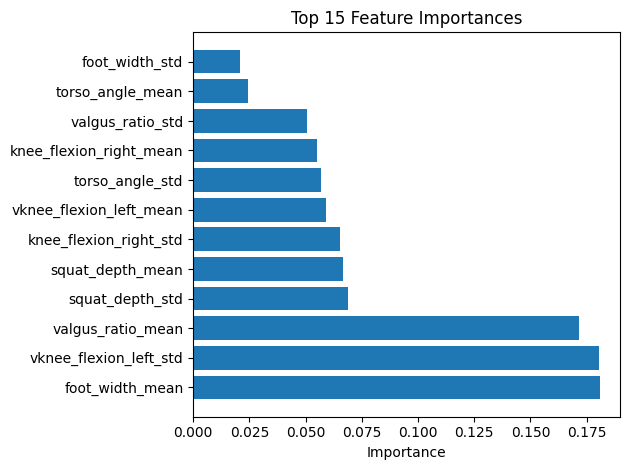

In [24]:
import matplotlib.pyplot as plt
importances = best_rf.feature_importances_
feature_names = X_test.columns
sorted_idx = importances.argsort()[::-1]

plt.barh(feature_names[sorted_idx][:15], importances[sorted_idx][:15])
plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


# SHAP

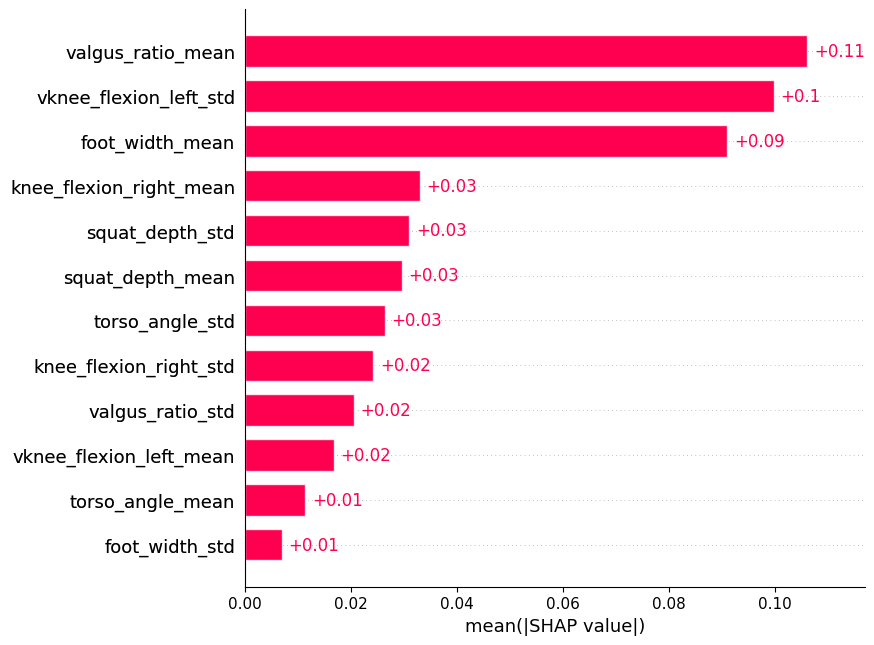

In [73]:
import shap
import joblib
import matplotlib.pyplot as plt

seed = seeds[0]  # or any seed from your evaluation list
set_seed(seed)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=seed
)


# Feature names (must match exactly)
feature_names = [
    "vknee_flexion_left_mean", "vknee_flexion_left_std",
    "knee_flexion_right_mean", "knee_flexion_right_std",
    "valgus_ratio_mean", "valgus_ratio_std",
    "torso_angle_mean", "torso_angle_std",
    "squat_depth_mean", "squat_depth_std",
    "foot_width_mean", "foot_width_std"
]

# Load the trained Random Forest model
rf_model = joblib.load("trained_models/rf_model_bio_features.pkl")  

# Create a properly labeled DataFrame
X_sample = pd.DataFrame(X_train, columns=feature_names)  # full 


# Use SHAP's new explainer
explainer = shap.Explainer(rf_model, X_sample)
shap_values = explainer(X_sample)

# Use only SHAP values for class 1 (index 1) - Bad squats
shap_values_class1 = shap_values.values[:, :, 0]

# Plot global bar chart
shap.plots.bar(shap.Explanation(
    values=shap_values_class1,
    base_values=shap_values.base_values[:, 0],
    data=X_sample.values,
    feature_names=X_sample.columns
), max_display=12)

